<a href="https://colab.research.google.com/github/vandanacm/spring-quarter-2026/blob/main/EEC289Q_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EEC 289Q - Homework 2: Logistic Regression and Regularization

This notebook presents the analysis and follows the assignment requirements: multiclass logistic regression on the Iris dataset, followed by ordinary least squares, Ridge, Lasso, and Elastic-Net regression on the California housing dataset.

## Part 1 - Logistic Regression on Iris

The Iris dataset is clean, labeled, and small enough to inspect visually. A pandas table is created first so the feature names, target encoding, and data shape are clear before plotting or fitting models.

In [ ]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

iris = load_iris()
X = iris.data
y = iris.target
feature_names = list(iris.feature_names)

df = pd.DataFrame(
    data=np.c_[iris.data, iris.target],
    columns=feature_names + ["target"],
)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


### Feature Visualization

Each feature is plotted against the target class to show how much separation is visible from one measurement alone. This helps explain why some single-feature models perform better than others and why the combined model should be strongest.

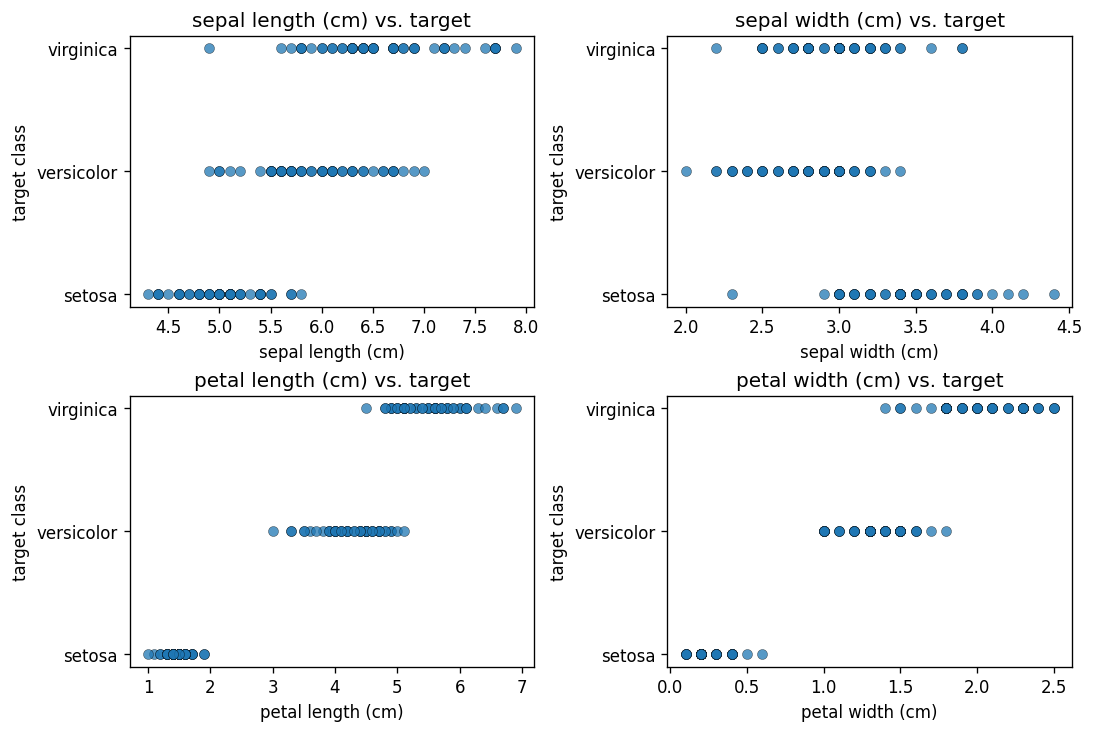

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), constrained_layout=True)
axes = axes.ravel()

for ax, fname in zip(axes, feature_names):
    ax.scatter(df[fname], df["target"], alpha=0.75, edgecolor="k", linewidth=0.25)
    ax.set_xlabel(fname)
    ax.set_ylabel("target class")
    ax.set_title(f"{fname} vs. target")
    ax.set_yticks([0, 1, 2], labels=iris.target_names)

plt.show()

### Train/Test Split

The data is split into 80% training and 20% testing with `random_state=42`. The model is fitted only on the training set and evaluated on test data so the reported metrics reflect performance on unseen samples.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((120, 4), (30, 4))

### Single-Feature and All-Feature Logistic Regression

A logistic regression model is trained once for each individual feature and once using all four features. This comparison shows which measurements carry signal on their own and how much performance improves when the model can combine features. Standardization is included because logistic regression uses regularization by default, and scaling keeps features on a comparable numerical basis.

In [ ]:
def classification_metrics(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mse_on_labels": mean_squared_error(y_true, y_pred),
        "r2_on_labels": r2_score(y_true, y_pred),
    }


def logistic_pipeline(C=1.0):
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(C=C, max_iter=5000, solver="lbfgs")),
    ])


rows = []
models_info = []

for j, fname in enumerate(feature_names):
    model = logistic_pipeline()
    model.fit(X_train[:, [j]], y_train)
    pred = model.predict(X_test[:, [j]])
    label = f"LR: {fname} only"
    rows.append(classification_metrics(label, y_test, pred))
    models_info.append((label, pred))

lr_all = logistic_pipeline()
lr_all.fit(X_train, y_train)
y_pred_all = lr_all.predict(X_test)
rows.append(classification_metrics("LR: all features", y_test, y_pred_all))
models_info.append(("LR: all features", y_pred_all))

metrics_df = pd.DataFrame(rows).set_index("model")
print("Classification report for the all-feature logistic regression model:\n")
print(classification_report(y_test, y_pred_all, target_names=iris.target_names, zero_division=0))
metrics_df

Classification report for the all-feature logistic regression model:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



,accuracy,precision_weighted,recall_weighted,f1_weighted,mse_on_labels,r2_on_labels
model,,,,,,
LR: sepal length (cm) only,0.833333,0.848889,0.833333,0.836190,0.166667,0.761526
LR: sepal width (cm) only,0.600000,0.583333,0.600000,0.582957,1.100000,-0.573927
LR: petal length (cm) only,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
LR: petal width (cm) only,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
LR: all features,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000


### Confusion Matrices

The confusion matrices show the specific class-level errors for each model. They are more informative than accuracy alone because two models can have similar accuracy while confusing different species.

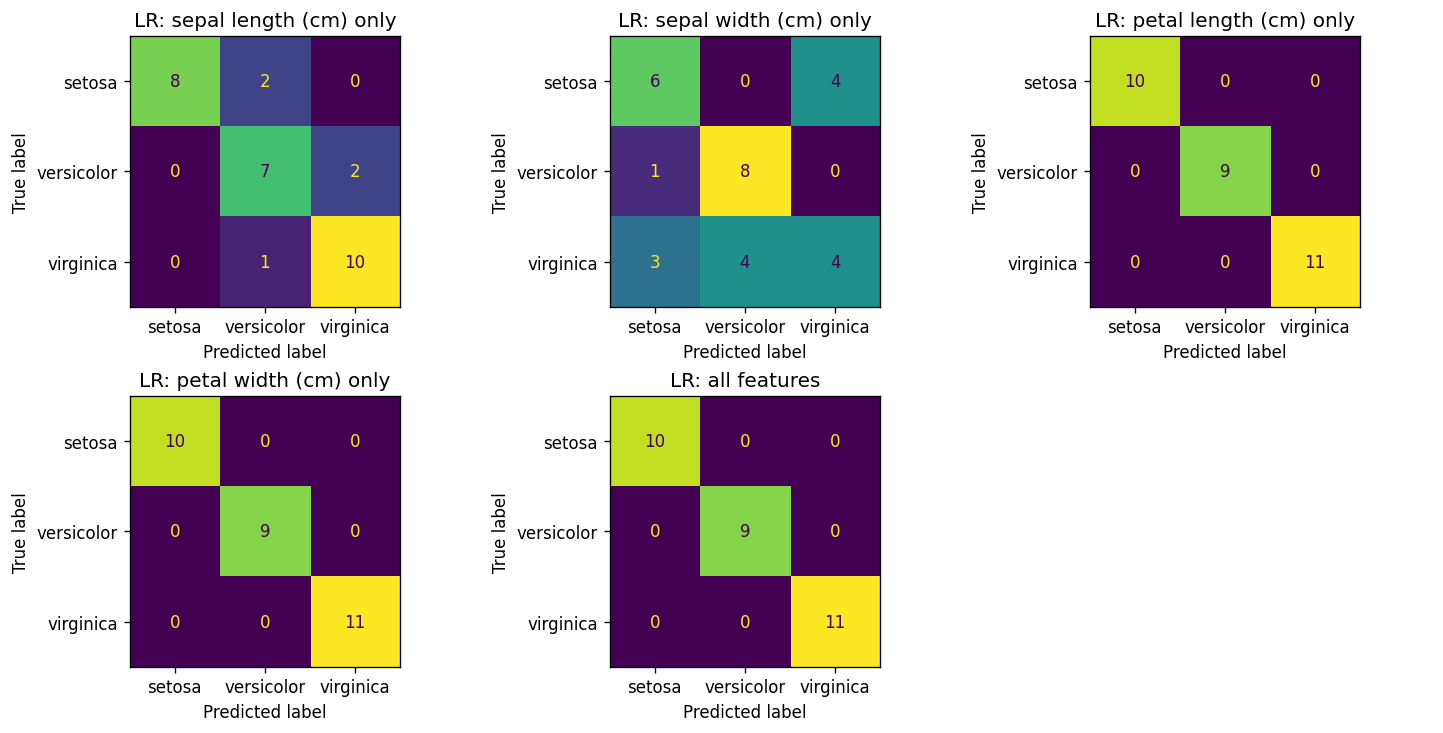

In [ ]:
n_models = len(models_info)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
axes = axes.ravel()

for ax, (name, pred) in zip(axes, models_info):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(
        ax=ax, colorbar=False, values_format="d"
    )
    ax.set_title(name)

for ax in axes[n_models:]:
    ax.axis("off")

plt.show()

### Logistic Regression Coefficients

For the all-feature multiclass model, each class has one coefficient per feature plus an intercept. A positive coefficient increases that class score relative to the other class scores after softmax normalization; a negative coefficient lowers it. These values are model-based associations, not causal effects.

In [ ]:
lr_model = lr_all.named_steps["model"]
coef_tbl = pd.DataFrame(
    lr_model.coef_,
    columns=feature_names,
    index=[f"class {i}: {name}" for i, name in enumerate(iris.target_names)],
)
coef_tbl["intercept"] = lr_model.intercept_
coef_tbl

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),intercept
class 0: setosa,-1.003166,1.144873,-1.811348,-1.69251,-0.133772
class 1: versicolor,0.527990,-0.283200,-0.340607,-0.72014,1.982646
class 2: virginica,0.475175,-0.861673,2.151955,2.41265,-1.848874


### Logistic Regression results on Iris

The petal measurements provide stronger class separation than the sepal measurements. The all-feature logistic regression model gives the strongest and most stable result because it combines information across measurements. On this split, the all-feature model is essentially perfect on the test set, which is reasonable for Iris because the species are highly separable when petal length and petal width are included.

## Part 2 - California Housing: Linear Regression with Regularization

The California housing dataset is a regression problem. The target is median house value in units of hundreds of thousands of dollars. Linear regression gives the baseline, while Ridge, Lasso, and Elastic-Net show how regularization changes predictive performance and coefficient behavior.

In [ ]:
cal = fetch_california_housing()
Xc = cal.data
yc = cal.target
housing_features = list(cal.feature_names)

housing_df = pd.DataFrame(Xc, columns=housing_features)
housing_df["MedHouseVal"] = yc
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Train/Test Split

The California housing data is split using the same 80/20 rule and `random_state=42`. This keeps the model comparison fair because every model is trained and tested on the same observations.

In [ ]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42
)

Xc_train.shape, Xc_test.shape

((16512, 8), (4128, 8))

### Required Models with Alpha = 0.01

The assignment asks for ordinary least squares and Ridge, Lasso, and Elastic-Net with `alpha=0.01`. The regularized models are placed in scaling pipelines because penalties depend on coefficient size; without scaling, features measured on larger numerical scales can be penalized unfairly.

In [ ]:
def regression_metrics(name, model):
    pred = model.predict(Xc_test)
    return {
        "model": name,
        "test_r2": r2_score(yc_test, pred),
        "test_mse": mean_squared_error(yc_test, pred),
    }


lin = LinearRegression().fit(Xc_train, yc_train)
ridge001 = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=0.01))]).fit(Xc_train, yc_train)
lasso001 = Pipeline([("scale", StandardScaler()), ("model", Lasso(alpha=0.01, max_iter=100000))]).fit(Xc_train, yc_train)
enet001 = Pipeline([("scale", StandardScaler()), ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=100000))]).fit(Xc_train, yc_train)

reg_compare = pd.DataFrame([
    regression_metrics("LinearRegression", lin),
    regression_metrics("Ridge(alpha=0.01)", ridge001),
    regression_metrics("Lasso(alpha=0.01)", lasso001),
    regression_metrics("ElasticNet(alpha=0.01, l1_ratio=0.5)", enet001),
]).set_index("model")

reg_compare

,test_r2,test_mse
model,,
LinearRegression,0.575788,0.555892
Ridge(alpha=0.01),0.575788,0.555891
Lasso(alpha=0.01),0.581615,0.548255
"ElasticNet(alpha=0.01, l1_ratio=0.5)",0.580319,0.549953


### Alpha Tuning and Coefficient Paths

The fixed `alpha=0.01` models satisfy the assignment. To strengthen the result, the notebook also uses a compact validation search to select alpha for Ridge, Lasso, and Elastic-Net, then plots coefficient paths across alpha. Ridge shrinks coefficients smoothly, Lasso can set coefficients exactly to zero, and Elastic-Net combines both behaviors.

In [ ]:
alphas = np.array([0.001, 0.01, 0.1, 1.0, 10.0])
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    Xc_train, yc_train, test_size=0.2, random_state=42
)


def choose_alpha(model_factory, model_label):
    validation_rows = []
    for alpha in alphas:
        model = Pipeline([("scale", StandardScaler()), ("model", model_factory(alpha))])
        model.fit(X_subtrain, y_subtrain)
        val_pred = model.predict(X_val)
        validation_rows.append((alpha, mean_squared_error(y_val, val_pred)))

    best_alpha = min(validation_rows, key=lambda item: item[1])[0]
    final_model = Pipeline([("scale", StandardScaler()), ("model", model_factory(best_alpha))])
    final_model.fit(Xc_train, yc_train)
    test_pred = final_model.predict(Xc_test)
    return {
        "model": model_label,
        "best_alpha": best_alpha,
        "validation_mse": min(v for _, v in validation_rows),
        "test_r2": r2_score(yc_test, test_pred),
        "test_mse": mean_squared_error(yc_test, test_pred),
    }


best_compare = pd.DataFrame([
    choose_alpha(lambda a: Ridge(alpha=a), "Ridge validation-tuned"),
    choose_alpha(lambda a: Lasso(alpha=a, max_iter=2000, tol=1e-2), "Lasso validation-tuned"),
    choose_alpha(lambda a: ElasticNet(alpha=a, l1_ratio=0.5, max_iter=2000, tol=1e-2), "ElasticNet validation-tuned"),
]).set_index("model")

best_compare

,best_alpha,validation_mse,test_r2,test_mse
model,,,,
Ridge validation-tuned,0.001,0.538606,0.575788,0.555892
Lasso validation-tuned,0.001,0.538632,0.576789,0.554579
ElasticNet validation-tuned,0.001,0.538672,0.576507,0.554950


### Coefficient Paths Across Alpha

The coefficient path plots show how increasing regularization strength changes the fitted model. The vertical dashed line marks the required `alpha=0.01` setting. Because the regularized models are scaled, the coefficient paths can be compared more fairly across features.

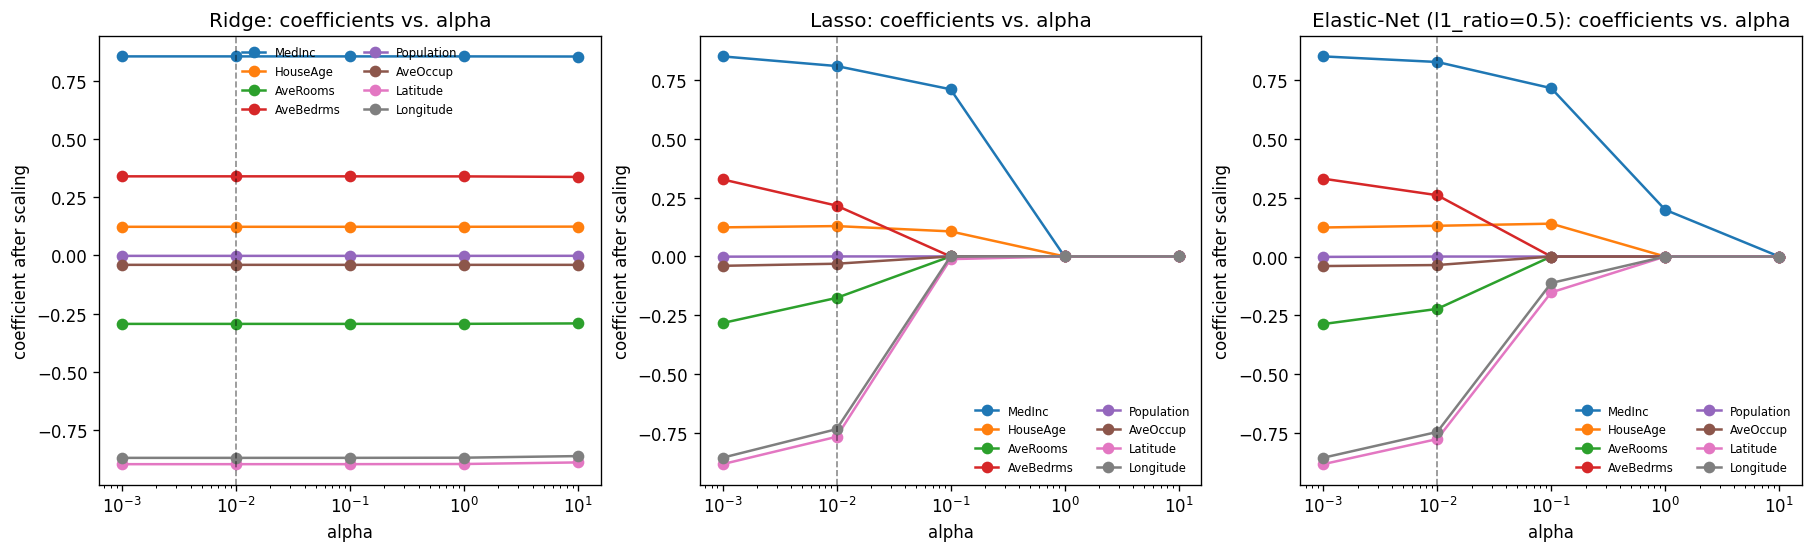

In [ ]:
def fit_scaled_path(model_factory, alphas):
    coefs = []
    for alpha in alphas:
        pipe = Pipeline([("scale", StandardScaler()), ("model", model_factory(alpha))])
        pipe.fit(Xc_train, yc_train)
        coefs.append(pipe.named_steps["model"].coef_)
    return np.vstack(coefs)


ridge_coefs = fit_scaled_path(lambda a: Ridge(alpha=a), alphas)
lasso_coefs = fit_scaled_path(lambda a: Lasso(alpha=a, max_iter=2000, tol=1e-2), alphas)
enet_coefs = fit_scaled_path(lambda a: ElasticNet(alpha=a, l1_ratio=0.5, max_iter=2000, tol=1e-2), alphas)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, coef_path, title in zip(
    axes,
    [ridge_coefs, lasso_coefs, enet_coefs],
    ["Ridge", "Lasso", "Elastic-Net (l1_ratio=0.5)"],
):
    for k, fname in enumerate(housing_features):
        ax.plot(alphas, coef_path[:, k], marker="o", label=fname)
    ax.set_xscale("log")
    ax.axvline(0.01, color="black", linestyle="--", linewidth=1, alpha=0.45)
    ax.set_title(f"{title}: coefficients vs. alpha")
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient after scaling")

axes[0].legend(ncol=2, fontsize=7, frameon=False)
axes[1].legend(ncol=2, fontsize=7, frameon=False)
axes[2].legend(ncol=2, fontsize=7, frameon=False)
plt.show()

### Logistic Regression results on housing

Ordinary least squares is the baseline because it minimizes squared error without a penalty. Ridge usually stays close to OLS at small alpha values while stabilizing coefficients. Lasso and Elastic-Net shrink less useful predictors more aggressively and can reduce some coefficients to zero as alpha increases. The tuned comparison uses cross-validation for model selection, which is more appropriate than manually choosing the best alpha from the test set.
